# Lesson 2.4 - Applied Stats for ML (Classification Metrics & Bias-Variance)

## Objectives
- Evaluate models using confusion matrix, precision, recall, F1, ROC-AUC.
- Visualize calibration quality.
- Demonstrate bias-variance tradeoff through model complexity.

In [1]:
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)
from sklearn.calibration import CalibrationDisplay

## Section A - Data Split and Leakage-Safe Pipeline

In [2]:
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000)),
    ]
)
clf.fit(X_train, y_train)
pred = clf.predict(X_test)
proba = clf.predict_proba(X_test)[:, 1]

## Section B - Core Classification Metrics

In [3]:
metrics = {
    "accuracy": accuracy_score(y_test, pred),
    "precision": precision_score(y_test, pred),
    "recall": recall_score(y_test, pred),
    "f1": f1_score(y_test, pred),
    "roc_auc": roc_auc_score(y_test, proba),
}

print({k: round(v, 4) for k, v in metrics.items()})
print("confusion_matrix:\n", confusion_matrix(y_test, pred))


{'accuracy': 0.986, 'precision': 0.9889, 'recall': 0.9889, 'f1': 0.9889, 'roc_auc': 0.9977}
confusion_matrix:
 [[52  1]
 [ 1 89]]


## Section C - Calibration Plot

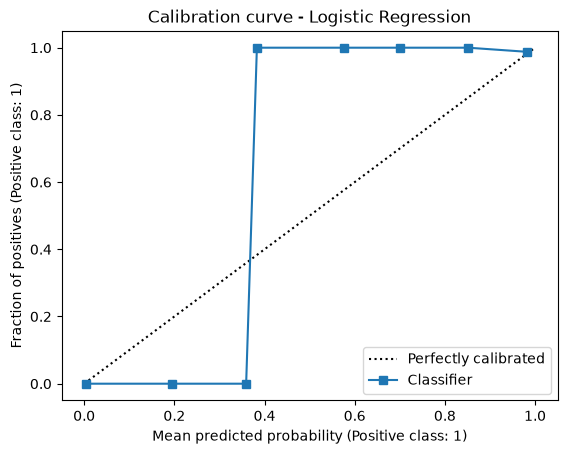

In [4]:
CalibrationDisplay.from_predictions(y_test, proba, n_bins=8)
plt.title("Calibration curve - Logistic Regression")
plt.show()

## Section D - Bias/Variance Demonstration via Tree Depth

Shallow tree: higher bias, lower variance.
Deep tree: lower bias, higher variance risk.

In [5]:
depths = [1, 2, 3, 5, 8, None]
rows = []
for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, tree.predict(X_train))
    test_acc = accuracy_score(y_test, tree.predict(X_test))
    rows.append((depth if depth is not None else -1, train_acc, test_acc))

for d, train_acc, test_acc in rows:
    label = "None" if d == -1 else str(d)
    print(f"max_depth={label:>4} | train_acc={train_acc:.4f} | test_acc={test_acc:.4f}")

max_depth=   1 | train_acc=0.9225 | test_acc=0.9231
max_depth=   2 | train_acc=0.9577 | test_acc=0.9091
max_depth=   3 | train_acc=0.9765 | test_acc=0.9441
max_depth=   5 | train_acc=0.9953 | test_acc=0.9371
max_depth=   8 | train_acc=1.0000 | test_acc=0.9231
max_depth=None | train_acc=1.0000 | test_acc=0.9231


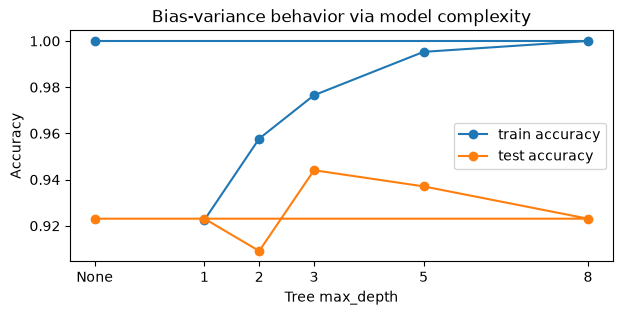

In [6]:
x = [d for d, _, _ in rows]
train_vals = [v for _, v, _ in rows]
test_vals = [v for _, _, v in rows]

plt.figure(figsize=(7, 3))
plt.plot(x, train_vals, marker="o", label="train accuracy")
plt.plot(x, test_vals, marker="o", label="test accuracy")
plt.xticks(x, ["1", "2", "3", "5", "8", "None"])
plt.xlabel("Tree max_depth")
plt.ylabel("Accuracy")
plt.title("Bias-variance behavior via model complexity")
plt.legend()
plt.show()

## Business Case Studies & Exceptions
- Accuracy alone can hide failures on minority classes.
- Calibration is mandatory when probability thresholds drive operations.
- Exception: if only ranking matters, calibration can be secondary but should still be monitored.

## Interview Questions & Answers
1. Precision vs recall? Precision controls false positives; recall controls false negatives.
2. Why is leakage dangerous? It inflates offline metrics and breaks trust in evaluation.